In [5]:
import os
os.getcwd()


'C:\\Users\\bhara\\OneDrive\\Desktop\\mutual fund analytics'

In [6]:
os.listdir()

['.git',
 '.ipynb_checkpoints',
 '.qodo',
 'bluestock_mf.db',
 'dashboard',
 'data',
 'dataclean+sql database.py',
 'data_dictionary.md',
 'data_dictionary_mf.db',
 'data_ingestion.py',
 'live_nav_fetch.py',
 'notebook',
 'performance_analytics.ipynb',
 'reports',
 'requirements.txt',
 'sql',
 'venv']

In [7]:
import os
os.getcwd()

'C:\\Users\\bhara\\OneDrive\\Desktop\\mutual fund analytics'

In [8]:
import os
os.getcwd()

'C:\\Users\\bhara\\OneDrive\\Desktop\\mutual fund analytics'

In [9]:
import os
os.getcwd()

'C:\\Users\\bhara\\OneDrive\\Desktop\\mutual fund analytics'

In [11]:
nav = pd.read_csv('data/raw/02_nav_history.csv')

In [12]:
import os
os.listdir('data/raw')

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'live_nav',
 'live_nav.csv']

In [13]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [16]:
nav = nav.sort_values(['amfi_code', 'date'])

In [17]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [18]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [19]:
nav.head(3)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865


In [20]:
(54.3474 / 54.3856) - 1

-0.0007023918095966364

In [21]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [22]:
nav['daily_return'].isna().sum()

np.int64(40)

In [23]:
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [24]:
nav['daily_return'].isna().sum()

np.int64(40)

In [25]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [26]:
nav['date'] = pd.to_datetime(nav['date'])
latest_date = nav['date'].max()
latest_date

Timestamp('2026-05-29 00:00:00')

In [27]:
three_years_ago = latest_date - pd.DateOffset(years=3)
three_years_ago

Timestamp('2023-05-29 00:00:00')

In [28]:
latest_nav = nav.groupby('amfi_code').last().reset_index()[['amfi_code', 'nav']]
latest_nav.head()

,amfi_code,nav
0,100016,583.6113
1,100025,31.8843
2,100033,342.0072
3,101206,773.2939
4,101207,53.9836


In [29]:
latest_nav = latest_nav.rename(columns={'nav': 'nav_end'})

In [30]:
start_nav = (
    nav[nav['date'] <= three_years_ago]
    .groupby('amfi_code')
    .last()
    .reset_index()[['amfi_code', 'nav']]
)

start_nav = start_nav.rename(columns={'nav': 'nav_start'})
start_nav.head()

,amfi_code,nav_start
0,100016,561.5519
1,100025,28.4135
2,100033,147.2155
3,101206,360.4971
4,101207,61.3081


In [31]:
cagr = latest_nav.merge(start_nav, on='amfi_code')
cagr.head()

,amfi_code,nav_end,nav_start
0,100016,583.6113,561.5519
1,100025,31.8843,28.4135
2,100033,342.0072,147.2155
3,101206,773.2939,360.4971
4,101207,53.9836,61.3081


In [33]:
cagr['cagr_3y'] = (cagr['nav_end'] / cagr['nav_start']) ** (1/3) - 1

In [34]:
cagr['cagr_3y_pct'] = cagr['cagr_3y'] * 100

In [35]:
cagr[['amfi_code', 'cagr_3y_pct']].head(10)

,amfi_code,cagr_3y_pct
0,100016,1.292649
1,100025,3.916390
2,100033,32.442459
3,101206,28.967695
4,101207,-4.152381
5,101208,6.315784
6,102885,19.667262
7,102886,-0.767406
8,102887,25.556188
9,118632,22.652360


In [36]:
cagr = cagr.sort_values('cagr_3y_pct', ascending=False)
cagr[['amfi_code', 'cagr_3y_pct']].head(10)

,amfi_code,cagr_3y_pct
16,119094,35.111802
34,148567,34.000916
24,120504,32.487429
2,100033,32.442459
25,120505,31.777537
19,119551,30.456524
30,120843,29.582770
36,148569,29.178902
3,101206,28.967695
39,149324,27.000427


In [37]:
cagr[['amfi_code', 'cagr_3y_pct']].head(10)

,amfi_code,cagr_3y_pct
16,119094,35.111802
34,148567,34.000916
24,120504,32.487429
2,100033,32.442459
25,120505,31.777537
19,119551,30.456524
30,120843,29.582770
36,148569,29.178902
3,101206,28.967695
39,149324,27.000427


In [38]:
cagr_table = cagr_table.round(2)
cagr_table.to_csv('reports/fund_scorecard.csv', index=False)

print(cagr_table.head(10))

NameError: name 'cagr_table' is not defined

In [39]:
cagr_1y = calculate_cagr(nav, 1)
cagr_1y.head()

NameError: name 'calculate_cagr' is not defined

In [40]:
def calculate_cagr(nav_df, years):
    # Latest date
    latest_date = nav_df['date'].max()

    # Date 'years' ago
    start_date = latest_date - pd.DateOffset(years=years)

    # Latest NAV for each fund
    latest_nav = (
        nav_df.groupby('amfi_code')
        .last()
        .reset_index()[['amfi_code', 'nav']]
        .rename(columns={'nav': 'nav_end'})
    )

    # NAV at or before the start date
    start_nav = (
        nav_df[nav_df['date'] <= start_date]
        .groupby('amfi_code')
        .last()
        .reset_index()[['amfi_code', 'nav']]
        .rename(columns={'nav': 'nav_start'})
    )

    # Merge start and end NAV
    cagr = latest_nav.merge(start_nav, on='amfi_code')

    # CAGR formula
    cagr[f'cagr_{years}y'] = (
        (cagr['nav_end'] / cagr['nav_start']) ** (1 / years)
    ) - 1

    # Convert to percentage
    cagr[f'cagr_{years}y_pct'] = cagr[f'cagr_{years}y'] * 100

    return cagr[['amfi_code', f'cagr_{years}y_pct']]

In [41]:
cagr_1y = calculate_cagr(nav, 1)
cagr_3y = calculate_cagr(nav, 3)
cagr_5y = calculate_cagr(nav, 5)

print(cagr_1y.head())
print(cagr_3y.head())
print(cagr_5y.head())

   amfi_code  cagr_1y_pct
0     100016    -2.224271
1     100025     3.704969
2     100033    53.232396
3     101206    47.924120
4     101207   -23.986032
   amfi_code  cagr_3y_pct
0     100016     1.292649
1     100025     3.916390
2     100033    32.442459
3     101206    28.967695
4     101207    -4.152381
Empty DataFrame
Columns: [amfi_code, cagr_5y_pct]
Index: []


In [42]:
cagr_table = (
    cagr_1y
    .merge(cagr_3y, on='amfi_code')
    .merge(cagr_5y, on='amfi_code')
)

cagr_table = cagr_table.round(2)
cagr_table.head()

,amfi_code,cagr_1y_pct,cagr_3y_pct,cagr_5y_pct


In [43]:
import os
os.makedirs('reports', exist_ok=True)

cagr_table.to_csv('reports/fund_scorecard.csv', index=False)

print('fund_scorecard.csv saved successfully!')

fund_scorecard.csv saved successfully!


In [44]:
# Annual risk-free rate
rf_annual = 0.065

# Convert to daily risk-free rate
rf_daily = rf_annual / 252

print(rf_daily)

0.00025793650793650796


In [45]:
sharpe = (
    nav.groupby('amfi_code')['daily_return']
    .agg(['mean', 'std'])
    .reset_index()
)

sharpe['sharpe_ratio'] = (
    (sharpe['mean'] - rf_daily) / sharpe['std']
) * np.sqrt(252)

sharpe = sharpe[['amfi_code', 'sharpe_ratio']]
sharpe = sharpe.round(3)

sharpe.head()

,amfi_code,sharpe_ratio
0,100016,-0.202
1,100025,-0.567
2,100033,1.094
3,101206,1.027
4,101207,0.163


In [46]:
sharpe.to_csv('reports/sharpe_ratio.csv', index=False)
print('sharpe_ratio.csv saved successfully!')

sharpe_ratio.csv saved successfully!


In [47]:
def calculate_sortino(group):
    returns = group['daily_return'].dropna()

    if len(returns) == 0:
        return np.nan

    downside = returns[returns < 0]

    if len(downside) == 0:
        return np.nan

    downside_std = downside.std()

    if downside_std == 0:
        return np.nan

    sortino = ((returns.mean() - rf_daily) / downside_std) * np.sqrt(252)

    return sortino

In [48]:
sortino = (
    nav.groupby('amfi_code')
    .apply(calculate_sortino)
    .reset_index(name='sortino_ratio')
)

sortino = sortino.round(3)
sortino.head()

,amfi_code,sortino_ratio
0,100016,-0.351
1,100025,-0.942
2,100033,1.829
3,101206,1.800
4,101207,0.277


In [49]:
sortino.to_csv('reports/sortino_ratio.csv', index=False)
print('sortino_ratio.csv saved successfully!')

sortino_ratio.csv saved successfully!


In [50]:
benchmark = pd.read_csv('data/raw/10_benchmark_indices.csv')
benchmark['date'] = pd.to_datetime(benchmark['date'])
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [51]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [52]:
# Keep only Nifty 100 benchmark
benchmark_100 = benchmark[benchmark['index_name'].str.contains('Nifty 100', case=False, na=False)].copy()

# Sort by date
benchmark_100 = benchmark_100.sort_values('date')

# Calculate benchmark daily returns
benchmark_100['benchmark_return'] = benchmark_100['close_value'].pct_change()

benchmark_100.head()

,date,index_name,close_value,benchmark_return


In [53]:
merged = nav.merge(
    benchmark_100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return


In [54]:
from scipy.stats import linregress

In [55]:
def calculate_alpha_beta(group):
    data = group[['daily_return', 'benchmark_return']].dropna()

    if len(data) < 30:
        return pd.Series({
            'alpha': np.nan,
            'beta': np.nan
        })

    result = linregress(
        data['benchmark_return'],
        data['daily_return']
    )

    beta = result.slope
    alpha = result.intercept * 252

    return pd.Series({
        'alpha': alpha,
        'beta': beta
    })

In [56]:
alpha_beta = (
    merged.groupby('amfi_code')
    .apply(calculate_alpha_beta)
    .reset_index()
)

alpha_beta = alpha_beta.round(4)

alpha_beta.head()

C:\Users\bhara\AppData\Local\Temp\ipykernel_20392\2519681108.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  alpha_beta = alpha_beta.round(4)


,amfi_code,date,nav,daily_return,benchmark_return


In [57]:
from scipy.stats import linregress
import pandas as pd
import numpy as np

def calculate_alpha_beta(group):
    data = group[['daily_return', 'benchmark_return']].dropna()

    if len(data) < 30:
        return pd.Series({
            'alpha': np.nan,
            'beta': np.nan
        })

    result = linregress(
        data['benchmark_return'],
        data['daily_return']
    )

    beta = result.slope
    alpha = result.intercept * 252

    return pd.Series({
        'alpha': alpha,
        'beta': beta
    })

In [58]:
alpha_beta = merged.groupby('amfi_code').apply(calculate_alpha_beta)

alpha_beta = alpha_beta.reset_index()

alpha_beta[['alpha', 'beta']] = alpha_beta[['alpha', 'beta']].round(4)

alpha_beta.head()

KeyError: "None of [Index(['alpha', 'beta'], dtype='str')] are in the [columns]"

In [59]:
alpha_beta = merged.groupby('amfi_code').apply(calculate_alpha_beta)
alpha_beta = alpha_beta.reset_index()

print(alpha_beta.columns)
alpha_beta.head()

Index(['amfi_code', 'date', 'nav', 'daily_return', 'benchmark_return'], dtype='str')


,amfi_code,date,nav,daily_return,benchmark_return


In [61]:
from scipy.stats import linregress

results = []

for fund in merged['amfi_code'].unique():
    df = merged[merged['amfi_code'] == fund][['daily_return', 'benchmark_return']].dropna()

    if len(df) < 30:
        continue

    result = linregress(df['benchmark_return'], df['daily_return'])

    results.append({
        'amfi_code': fund,
        'alpha': result.intercept * 252,
        'beta': result.slope
    })

alpha_beta = pd.DataFrame(results)

alpha_beta = alpha_beta.round(4)

alpha_beta.head()

""


In [62]:
print(merged.shape)
merged.head()

(0, 5)


,amfi_code,date,nav,daily_return,benchmark_return


In [63]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [64]:
benchmark_100 = benchmark[benchmark['index_name'].str.contains('100', case=False, na=False)]

print(benchmark_100.shape)
benchmark_100['index_name'].unique()

(1150, 3)


<StringArray>
['NIFTY100']
Length: 1, dtype: str

In [65]:
benchmark_100 = benchmark[benchmark['index_name'].str.contains('100', case=False, na=False)].copy()

benchmark_100 = benchmark_100.sort_values('date')
benchmark_100['benchmark_return'] = benchmark_100['close_value'].pct_change()

merged = nav.merge(
    benchmark_100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

print('Merged rows:', merged.shape[0])
merged.head()

Merged rows: 46000


,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [66]:
fund = merged['amfi_code'].iloc[0]

df = merged[merged['amfi_code'] == fund][['daily_return', 'benchmark_return']].dropna()

print(len(df))
df.head()

1149


,daily_return,benchmark_return
1,-0.010306,-0.013540
2,0.012865,0.004003
3,-0.011377,-0.002935
4,-0.001210,0.006150
5,-0.008639,-0.008351


In [67]:
from scipy.stats import linregress
import pandas as pd
import numpy as np

results = []

# Loop through each fund
for fund in merged['amfi_code'].unique():

    # Select one fund's returns
    df = merged.loc[
        merged['amfi_code'] == fund,
        ['daily_return', 'benchmark_return']
    ].dropna()

    # Skip if not enough data
    if len(df) < 30:
        continue

    # Regression
    reg = linregress(
        x=df['benchmark_return'],
        y=df['daily_return']
    )

    # Store alpha and beta
    results.append({
        'amfi_code': int(fund),
        'alpha': reg.intercept * 252,
        'beta': reg.slope
    })

# Create DataFrame
alpha_beta = pd.DataFrame(results)

# Round values
alpha_beta = alpha_beta.round({
    'alpha': 4,
    'beta': 4
})

print(alpha_beta.head())
print('Number of funds:', len(alpha_beta))

   amfi_code   alpha    beta
0     100016  0.0375 -0.0583
1     100025  0.0428  0.0012
2     100033  0.2720  0.0051
3     101206  0.2140  0.0211
4     101207  0.1090 -0.0653
Number of funds: 40


In [68]:
alpha_beta.to_csv('reports/alpha_beta.csv', index=False)
print('alpha_beta.csv saved successfully!')

alpha_beta.csv saved successfully!


In [69]:
nav = nav.sort_values(['amfi_code', 'date'])

nav['running_max'] = (
    nav.groupby('amfi_code')['nav']
    .cummax()
)

nav.head()

,amfi_code,date,nav,daily_return,running_max
5750,100016,2022-01-03,520.4608,NaN,520.4608
5751,100016,2022-01-04,515.0971,-0.010306,520.4608
5752,100016,2022-01-05,521.7239,0.012865,521.7239
5753,100016,2022-01-06,515.7880,-0.011377,521.7239
5754,100016,2022-01-07,515.1639,-0.001210,521.7239


In [70]:
nav['drawdown'] = (
    nav['nav'] / nav['running_max']
) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [71]:
max_drawdown = (
    nav.groupby('amfi_code')['drawdown']
    .min()
    .reset_index()
)

max_drawdown = max_drawdown.rename(
    columns={'drawdown': 'max_drawdown'}
)

max_drawdown['max_drawdown_pct'] = (
    max_drawdown['max_drawdown'] * 100
).round(2)

max_drawdown.head()

,amfi_code,max_drawdown,max_drawdown_pct
0,100016,-0.247344,-24.73
1,100025,-0.043083,-4.31
2,100033,-0.162172,-16.22
3,101206,-0.112916,-11.29
4,101207,-0.354469,-35.45


In [72]:
max_drawdown = max_drawdown.sort_values(
    'max_drawdown_pct',
    ascending=True
)

max_drawdown.head(10)

,amfi_code,max_drawdown,max_drawdown_pct
22,119599,-0.525742,-52.57
17,119095,-0.516778,-51.68
4,101207,-0.354469,-35.45
39,149324,-0.311719,-31.17
21,119598,-0.287060,-28.71
7,102886,-0.280011,-28.00
0,100016,-0.247344,-24.73
29,120842,-0.240035,-24.00
11,118634,-0.233449,-23.34
15,119093,-0.217514,-21.75


In [73]:
max_drawdown.to_csv(
    'reports/max_drawdown.csv',
    index=False
)

print('max_drawdown.csv saved successfully!')

max_drawdown.csv saved successfully!


In [74]:
top5 = cagr_table.sort_values(
    'cagr_3y_pct',
    ascending=False
).head(5)

top5_codes = top5['amfi_code'].tolist()

print(top5_codes)

[]


In [75]:
start_date = latest_date - pd.DateOffset(years=3)

fund_data = nav[
    (nav['amfi_code'].isin(top5_codes)) &
    (nav['date'] >= start_date)
].copy()

fund_data.head()

,amfi_code,date,nav,daily_return,running_max,drawdown


In [76]:
fund_data['normalized_nav'] = (
    fund_data.groupby('amfi_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

fund_data.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,normalized_nav


In [77]:
benchmark_3y = benchmark[
    benchmark['date'] >= start_date
].copy()

benchmark_3y['normalized_close'] = (
    benchmark_3y.groupby('index_name')['close_value']
    .transform(lambda x: x / x.iloc[0] * 100)
)

benchmark_3y.head()

,date,index_name,close_value,normalized_close
365,2023-05-29,NIFTY50,24688.69,100.000000
366,2023-05-30,NIFTY50,24558.17,99.471337
367,2023-05-31,NIFTY50,24476.07,99.138796
368,2023-06-01,NIFTY50,24375.89,98.733023
369,2023-06-02,NIFTY50,24398.93,98.826345


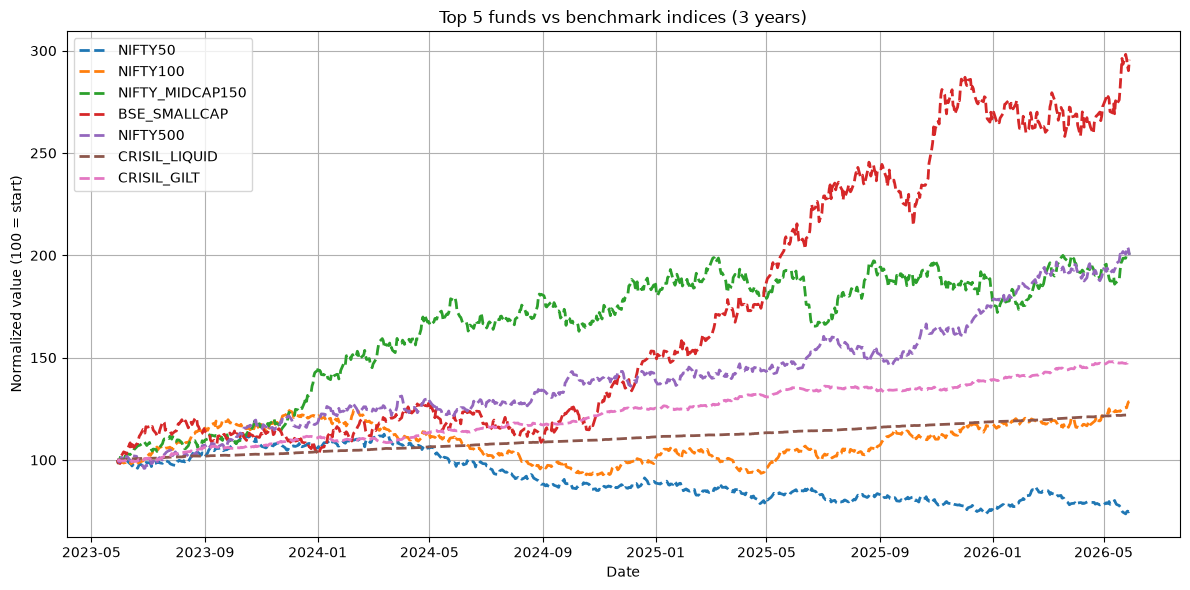

In [78]:
plt.figure(figsize=(12, 6))

# Plot top 5 funds
for code in top5_codes:
    temp = fund_data[fund_data['amfi_code'] == code]
    plt.plot(
        temp['date'],
        temp['normalized_nav'],
        label=f'Fund {code}',
        linewidth=2
    )

# Plot benchmarks
for idx in benchmark_3y['index_name'].unique():
    temp = benchmark_3y[
        benchmark_3y['index_name'] == idx
    ]
    plt.plot(
        temp['date'],
        temp['normalized_close'],
        label=idx,
        linestyle='--',
        linewidth=2
    )

plt.title('Top 5 funds vs benchmark indices (3 years)')
plt.xlabel('Date')
plt.ylabel('Normalized value (100 = start)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    'reports/benchmark_comparison.png',
    dpi=300
)

plt.show()

In [79]:
tracking_error = []

for code in top5_codes:

    df = merged[merged['amfi_code'] == code][
        ['daily_return', 'benchmark_return']
    ].dropna()

    te = (
        (df['daily_return'] - df['benchmark_return']).std()
        * np.sqrt(252)
    )

    tracking_error.append({
        'amfi_code': code,
        'tracking_error': round(te, 4)
    })

tracking_error = pd.DataFrame(tracking_error)

tracking_error.to_csv(
    'reports/tracking_error.csv',
    index=False
)

tracking_error

""


In [80]:
print('Results length:', len(results))
print(alpha_beta.shape)
alpha_beta.head()

Results length: 40
(40, 3)


,amfi_code,alpha,beta
0,100016,0.0375,-0.0583
1,100025,0.0428,0.0012
2,100033,0.2720,0.0051
3,101206,0.2140,0.0211
4,101207,0.1090,-0.0653


In [81]:
print('Merged shape:', merged.shape)
print('Unique funds:', merged['amfi_code'].nunique())

fund = merged['amfi_code'].iloc[0]
df = merged[merged['amfi_code'] == fund][['daily_return', 'benchmark_return']].dropna()

print('Rows for first fund:', len(df))
print(df.head())

Merged shape: (46000, 5)
Unique funds: 40
Rows for first fund: 1149
   daily_return  benchmark_return
1     -0.010306         -0.013540
2      0.012865          0.004003
3     -0.011377         -0.002935
4     -0.001210          0.006150
5     -0.008639         -0.008351


In [82]:
from scipy.stats import linregress

alpha_list = []

for fund in merged['amfi_code'].unique():
    df = merged[merged['amfi_code'] == fund][['daily_return', 'benchmark_return']].dropna()

    reg = linregress(df['benchmark_return'], df['daily_return'])

    alpha_list.append({
        'amfi_code': fund,
        'alpha': round(reg.intercept * 252, 4),
        'beta': round(reg.slope, 4)
    })

alpha_beta = pd.DataFrame(alpha_list)

print(alpha_beta.shape)
alpha_beta.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.0375,-0.0583
1,100025,0.0428,0.0012
2,100033,0.2720,0.0051
3,101206,0.2140,0.0211
4,101207,0.1090,-0.0653


In [83]:
alpha_beta.head(10)

,amfi_code,alpha,beta
0,100016,0.0375,-0.0583
1,100025,0.0428,0.0012
2,100033,0.2720,0.0051
3,101206,0.2140,0.0211
4,101207,0.1090,-0.0653
5,101208,0.0609,0.0003
6,102885,0.1705,-0.0195
7,102886,0.0290,-0.0421
8,102887,0.1621,0.0167
9,118632,0.2183,-0.0084


In [84]:
alpha_beta.to_csv('reports/alpha_beta.csv', index=False)
print('alpha_beta.csv saved successfully!')

alpha_beta.csv saved successfully!


In [85]:
final_scorecard = (
    cagr_table
    .merge(sharpe, on='amfi_code')
    .merge(sortino, on='amfi_code')
    .merge(alpha_beta, on='amfi_code')
    .merge(max_drawdown[['amfi_code', 'max_drawdown_pct']], on='amfi_code')
)

final_scorecard.head()

,amfi_code,cagr_1y_pct,cagr_3y_pct,cagr_5y_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown_pct


In [86]:
final_scorecard = (
    cagr_table
    .merge(sharpe, on='amfi_code')
    .merge(sortino, on='amfi_code')
    .merge(alpha_beta, on='amfi_code')
    .merge(max_drawdown[['amfi_code', 'max_drawdown_pct']], on='amfi_code')
)

final_scorecard.head()

,amfi_code,cagr_1y_pct,cagr_3y_pct,cagr_5y_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown_pct


In [87]:
# Higher CAGR is better
final_scorecard['rank_cagr'] = final_scorecard['cagr_3y_pct'].rank(ascending=False)

# Higher Sharpe is better
final_scorecard['rank_sharpe'] = final_scorecard['sharpe_ratio'].rank(ascending=False)

# Higher Alpha is better
final_scorecard['rank_alpha'] = final_scorecard['alpha'].rank(ascending=False)

# Less negative drawdown is better
final_scorecard['rank_dd'] = final_scorecard['max_drawdown_pct'].rank(ascending=False)

final_scorecard.head()

,amfi_code,cagr_1y_pct,cagr_3y_pct,cagr_5y_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown_pct,rank_cagr,rank_sharpe,rank_alpha,rank_dd


In [88]:
n = len(final_scorecard)

# Convert ranks into 0-100 scores
for col in ['rank_cagr', 'rank_sharpe', 'rank_alpha', 'rank_dd']:
    score_col = col.replace('rank_', 'score_')
    final_scorecard[score_col] = (
        (n - final_scorecard[col]) / (n - 1)
    ) * 100

# Weighted composite score
final_scorecard['fund_score'] = (
    0.30 * final_scorecard['score_cagr'] +
    0.25 * final_scorecard['score_sharpe'] +
    0.20 * final_scorecard['score_alpha'] +
    0.10 * final_scorecard['score_dd']
)

final_scorecard = final_scorecard.round(2)

final_scorecard.head()

,amfi_code,cagr_1y_pct,cagr_3y_pct,cagr_5y_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown_pct,rank_cagr,rank_sharpe,rank_alpha,rank_dd,score_cagr,score_sharpe,score_alpha,score_dd,fund_score


In [89]:
final_scorecard = final_scorecard.sort_values(
    'fund_score',
    ascending=False
)

final_scorecard[['amfi_code',
                 'cagr_3y_pct',
                 'sharpe_ratio',
                 'alpha',
                 'max_drawdown_pct',
                 'fund_score']].head(10)

,amfi_code,cagr_3y_pct,sharpe_ratio,alpha,max_drawdown_pct,fund_score


In [90]:
final_scorecard.to_csv(
    'reports/fund_scorecard.csv',
    index=False
)

print('Final fund_scorecard.csv saved successfully!')

Final fund_scorecard.csv saved successfully!


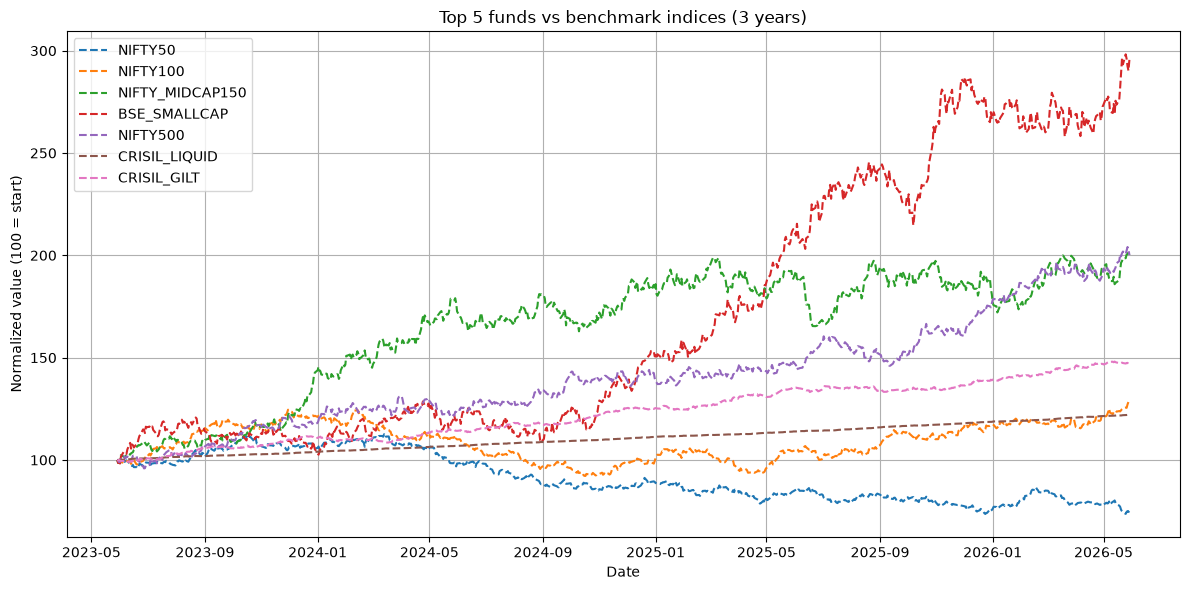

benchmark_comparison.png saved successfully!


In [91]:
top5_codes = final_scorecard.head(5)['amfi_code'].tolist()

start_date = latest_date - pd.DateOffset(years=3)

fund_data = nav[
    (nav['amfi_code'].isin(top5_codes)) &
    (nav['date'] >= start_date)
].copy()

fund_data['normalized_nav'] = (
    fund_data.groupby('amfi_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

benchmark_3y = benchmark[
    benchmark['date'] >= start_date
].copy()

benchmark_3y['normalized_close'] = (
    benchmark_3y.groupby('index_name')['close_value']
    .transform(lambda x: x / x.iloc[0] * 100)
)

plt.figure(figsize=(12,6))

for code in top5_codes:
    temp = fund_data[fund_data['amfi_code'] == code]
    plt.plot(temp['date'],
             temp['normalized_nav'],
             label=f'Fund {code}')

for idx in benchmark_3y['index_name'].unique():
    temp = benchmark_3y[benchmark_3y['index_name'] == idx]
    plt.plot(temp['date'],
             temp['normalized_close'],
             label=idx,
             linestyle='--')

plt.title('Top 5 funds vs benchmark indices (3 years)')
plt.xlabel('Date')
plt.ylabel('Normalized value (100 = start)')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    'reports/benchmark_comparison.png',
    dpi=300
)

plt.show()

print('benchmark_comparison.png saved successfully!')